# Data Driven Project
This Notebook will serve as a submission for the Artificial Intelligence Module, sat in ITTralee, by Daniel Jameson T00158237

# Subject of Report
This report will examine bicycle rental data in Dublin, Ireland, with the purpose of gathering rental data on the subject, to determine what kind of influence outside factors have on the rate of rentals.

Any such investigation would expect to find correlative data suggesting that rentals were increased around certain patterns, for example, less rentals in rainy conditions, as people would rather drive in an enclosed vehicle instead of being exposed to the elements.

# Data

<hr>

## Bike Rental Data
This report sources it's data from SmartDublin.ie, as the Data.gov.ie site has worse quality data.
The exact bike rental data set [can be found here](https://data.smartdublin.ie/dataset/dublinbikes-api), and the data set starts at January, 2024. These data sets are maintained and generated by Dublin City Council.

*Note that the year 2024 was chosen here because of its' small relative size. The equivalent data set from 2025 was 75mb in size, whereas the 2024 data only occupies < 19mb of data. This was a limitation of resources.*

## Further Note
Unfortunately, because of the chosen data, January, being a quiet month, there was not a massive amount of rentals. This site and it's data are really bad, and my original plan was to compose multiple months of data into one data set. This was not possible, as alternating months have different layouts.

<hr>

## Weather Data
The weather data used in this set was sourced from Gov.ie, and it is part of an hourly collection service from Phoenix Park. Phoenix Park was chosen because of it's closer proximity to bike stations in the first data set. The data set was found [here](https://data.gov.ie/dataset/phoenix-park-hourly-data) and will be standardised and added to the Bike data set.

# Data Set Exploration
## Bike Data Set
![Bike Sample](https://drive.google.com/uc?id=10wuLoA4QWRD9vrSn6jdUoojxmr__oTjt)
The Bike data set has fields that correspond to the following features:
- _Id = Column number for the data.
- STATION ID = The ID number for the station in question. It should be noted that there is no station 46 in this data set, and it is missing on every entry.
- TIME = The Time the recording was taken, in standardised [ISO 8601](https://www.iso.org/iso-8601-date-and-time-format.html) format.
- LAST UPDATED = Last updated timestamp for the individual station. Also in ISO 6801 format.
- NAME - Name of the station in question.
- BIKE STANDS - Number of total bike stands.
- AVAILABLE BIKE STANDS - The number of bike stands for a bike to be placed. As in, no bike on the stand.
- AVAILABLE BIKES - The number of bikes remaining on their stands.
- STATUS - No idea, the value for this is always "OPEN". It's just going to be dropped.
- ADDRESS - The Address of the station. This always holds the same value as the "NAME" column, just in lower-case.
- LATITUDE - This specifies a position on an East-West axis.
- LONGITUDE - This specifies a position on the North-South axis.

*Latitude and Longitude give you the position of the station.*

<hr>

## Weather Data Set
![Weather Data Sample](https://drive.google.com/uc?id=1fpnAn0yU6kMaZqgVPd6iasdC_hn2x8Bh)

The Weather Data Set holds the following features that will be added to the bike data set to make a complete set to draw better conclusions from than any singular data set. The columns mean the following:
- date: This specifies the Date in a DD/MM/YYYY format, with the hour starting at the 0th minute after, as in 23:00, whereas the timestamp from the previous data set was the ISO 8601 standard.
- rain: This statistic measures rainfall at the given recorder at the given hour.
- temp: This measures the temperature at the given weather station.
- wetb: Wet Bulb Temperature - This is the lowest temperature that can be reached under current ambient conditions by the evaporation of water only.
- dewpt: Dew Point - This is the temperature to which air must be cooled to reach 100% relative humidity.
- vappr: Vapour Pressure - This is the pressure exerted by a vapor in thermodynamic equilibrium with its condensed phases, either liquid or solid, at a given temperature in a closed system.
- rhum: Relative Humidity - This is th erelative level of moisture being held by the air.
- msl: Mean Sea Level Pressure - This measures the atmospheric pressure at a location, relative to sea level.
- ind: This represents multiple columns, only ever holds zero, and should be considered irrelevant. These Columns will all be removed.

# Plan for this Project
This project aims to predict trends in bicycle rentals in Dublin city. Travellers have various methods available to them in terms of reaching a destination. Public Transport, Personal Transport(Vehicles) and Bike rentals to commute, explore and other reasons for travelling.

The assumption is that external factors such as weather and holidays may increase or decrease the rate of rentals.

This report proposes a model that examines the external factors that may have causal links in the rate of bike rentals.

To Exercise this proposed model, the following steps will need to be accomplished:
<hr>

## Steps
- **Data Cleaning:**
The data from the two sets will have to be heavily modified to remove irrelavant data, merging the datasets where values are the same and standardising the necessary fields, like the time field.
- **Model Preparation:**
Decide on the necessary features and approach to model those features. Suggestions for this include [Gradient Boosting](https://www.ibm.com/think/topics/gradient-boosting), Random Forest Regressor, etc. The reason for selecting such an approach is that there may be many factors that influence a decision to rent vs. drive, and they may not all correlate in the same way, so a singular neural network or tree would not be the best approach for such a multi-faceted problem.
- **Evaluation:**
Evaluating the model with several metrics such as MSE and MAE should determine the accuracy of the model. The model will assume that tolerances are tight on this data set. The rental rate for Dublin in January should not be too high of a number.

# Imports
This section will hold the necessary library imports for the project and mount the Google Drive instance which holds the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
drive.mount('/MachineLearningProjectData', force_remount=True)

Mounted at /MachineLearningProjectData


# Load in and Clean Files
For the purposes of this report, the files are stored on OneDrive, and can be accessed with the following Python line: `pd.read_csv('DublinBikes-2024-01.csv')`
Access is a bit difficult, so I'm storing the commands to access the files here.
`!ls /MachineLearningProjectData/MyDrive/MachineLearningProjectData/Filename.csv`

## Cleaning the Data - Bikes
The data can first be cleaned by removing the irrelevant fields. The folowing fields can safely be removed:
- _id: This corresponds to a row identifier. It is not necessary, as it does not hold any relevant information for the model.
- LAST UPDATED: This is also irrelevant information, as it only describes the time the stations data was refreshed, and is not a recording of the number of stands, or any other relevant data.
- STATUS: This value is only ever the word "OPEN", and does not appear to correspond to anything of value.
- ADDRESS: This is only a lowercase alternative to the name of the station. The data set web page describes it as a short version of the same STATION field, but only ever appears to have the same value as STATION in any case.

### Standardising the time fields
#### Format
The time will have to be standardised into the same time format, so they can be handled programmatically in the same manner.
- **Bike Set:** Drop data for half-hour intervals, as rounding would produce hourly values, which is already in the data set.

#### Rounding the Data
The time numbers are taken for the bike rentals are every half an hour. meanwhile, the weather data is updated every hour. Because weather data does not change very much over the course over a single hour, it makes sense here to round all data to the nearest hour. Then, rounding the weather data to the same time as the existing bike rentals gives a clear picture as to what's happening at that given time.

In [2]:
# Bike Rental Data Cleaning
rental_data = pd.read_csv('/MachineLearningProjectData/MyDrive/MachineLearningProjectData/DublinBikes-2024-01.csv')
rental_data.drop(columns=["_id", "LAST UPDATED", "STATUS", "ADDRESS"], inplace=True)
print(rental_data.head())

   STATION ID                 TIME                NAME  BIKE_STANDS  \
0           1  2024-01-01T00:00:02       CLARENDON ROW           31   
1           2  2024-01-01T00:00:02  BLESSINGTON STREET           20   
2           3  2024-01-01T00:00:02       BOLTON STREET           20   
3           4  2024-01-01T00:00:02        GREEK STREET           20   
4           5  2024-01-01T00:00:02    CHARLEMONT PLACE           40   

   AVAILABLE_BIKE_STANDS  AVAILABLE_BIKES  LATITUDE  LONGITUDE  
0                      8               23   53.3409   -6.26250  
1                     18                2   53.3568   -6.26814  
2                     18                2   53.3512   -6.26986  
3                     10               10   53.3469   -6.27298  
4                      8               32   53.3307   -6.26018  


## Cleaning the Data - Weather
The weather data can be cleaned in one major way, and the rest are minor.
The main cleaning should be removing the irrelevant dates, as this set starts in August 2003, and finishes in August 2025. This means that 22 years worth of data can be removed.

The rest can be described as more or less relevant data from the set. For example, rainfall should be considered more important than msl(Mean Sea Level Pressure). Pressure won't have any discernable impact on rentals, but rainfall would. I have implemented the following prioritisation list for the data fields.
### More Important Features
- Temperature. Colder conditions are likely to prevent people from considering cycling as a method of travel, as it can lead to snow and other adverse conditions.
- Rainfall. Rain can lead to treacherous conditions, such as puddles that tyres can aquaplane over and discomfort as people get wet.
- Humidity. Humidity increases the demand required to progress and introduces more discomfort.

### Less Important Features
- ind. These columns don't do anything. They've been removed.
- wetb. Wet Bulb Temperature won't have any major effect on cyclist performance or comfort.
- dewpt. Like wetb above, performs as a stand-in for humidity, which is not more important than actual humidity measurements.
- vappr and msl. Vapour pressure won't have any discernable impact on cycling conditions, and shouldn't be considered for the same reasons as above.

In [3]:
# Weather Data Cleaning. Quick note about the skiprows, this was done because the CSV file had a header that didn't correspond to the actual data in the file. Python had a problem with that.
weather_data = pd.read_csv('/MachineLearningProjectData/MyDrive/MachineLearningProjectData/MonthlyWeatherPhoenixPark.csv', skiprows=14)
weather_data.drop(columns=["ind", "ind.1", "ind.2", "wetb", "dewpt", "vappr", "msl"], inplace=True)
weather_data['date'] = pd.to_datetime(weather_data['date'], format='%d-%b-%Y %H:%M')

# Isolate January 2024 data using to_datetime() method.
weather_jan_2024 = weather_data[
    (weather_data['date'].dt.year == 2024) &
    (weather_data['date'].dt.month == 1)
]

print(weather_jan_2024.head())
print(weather_jan_2024.tail()) # Print a sample of tail and head to check whether boundary values are correct.

/tmp/ipython-input-1020680700.py:2: DtypeWarning: Columns (2,4,6,7,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_data = pd.read_csv('/MachineLearningProjectData/MyDrive/MachineLearningProjectData/MonthlyWeatherPhoenixPark.csv', skiprows=14)


                      date rain temp rhum
178631 2024-01-01 00:00:00  0.0  6.1   84
178632 2024-01-01 01:00:00  0.0  5.4   86
178633 2024-01-01 02:00:00  0.0  5.1   83
178634 2024-01-01 03:00:00  0.0  5.0   82
178635 2024-01-01 04:00:00  0.0  4.9   84
                      date rain temp rhum
179370 2024-01-31 19:00:00  0.0  5.7   94
179371 2024-01-31 20:00:00  0.0  5.9   93
179372 2024-01-31 21:00:00  0.1  4.9   92
179373 2024-01-31 22:00:00  0.0  4.3   91
179374 2024-01-31 23:00:00  0.0  4.1   89


## Standardising the Dates
Both sets of dates need to be in the same format to be manipulated. For this, a date format that is easily manipulated by Python would be the obvious choice to use. The `to_datetime()` method seems a suitable choice, as it would make merging the set easier later.

In [4]:
# Standardise the Dates in each Data Frame. Test.
weather_jan_2024['datetime'] = pd.to_datetime(weather_jan_2024['date'])
rental_data['datetime'] = pd.to_datetime(rental_data['TIME'])

# Make new dataframe from only hourly data.
rental_data_hourly = rental_data[rental_data['datetime'].dt.minute <= 2]
weather_jan_2024.drop(columns=["date"], inplace=True)
rental_data.drop(columns=["TIME"], inplace=True)

# Round bike rental times to nearest hour for merging
rental_data_hourly['datetime_rounded'] = rental_data_hourly['datetime'].dt.round('H')

# Merge on the rounded datetime
merged_df = pd.merge(rental_data_hourly, weather_jan_2024,
                     left_on='datetime_rounded',
                     right_on='datetime',
                     how='left')

# Drop columns created by merging
merged_df.drop(columns=['datetime_x', 'datetime_y', 'TIME'], inplace=True)
print(merged_df.sample(5))

       STATION ID              NAME  BIKE_STANDS  AVAILABLE_BIKE_STANDS  \
11579          67         THE POINT           40                     36   
61501          57    GRATTAN STREET           23                      9   
36583         107  CHARLEVILLE ROAD           40                     21   
8255           49      GUILD STREET           40                     36   
51686          45    DEVERELL PLACE           30                      0   

       AVAILABLE_BIKES  LATITUDE  LONGITUDE    datetime_rounded rain  temp  \
11579                4   53.3469   -6.23085 2024-01-05 05:00:00  0.0   3.4   
61501               14   53.3396   -6.24378 2024-01-23 13:00:00  0.0  14.3   
36583               19   53.3592   -6.28187 2024-01-14 08:00:00  0.0   0.6   
8255                 4   53.3479   -6.24093 2024-01-04 00:00:00  0.0   7.4   
51686               30   53.3515   -6.25527 2024-01-19 23:00:00  0.0   6.7   

      rhum  
11579   96  
61501   86  
36583   95  
8255    89  
51686   64  


/tmp/ipython-input-2055436061.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_jan_2024['datetime'] = pd.to_datetime(weather_jan_2024['date'])
/tmp/ipython-input-2055436061.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_jan_2024.drop(columns=["date"], inplace=True)
/tmp/ipython-input-2055436061.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rental_data_hourly['datetime_rounded'] = rental_data_hourly['datetime'].dt.round('H')
/tmp/ipython-input-2055436061.py:11: SettingWithCopyWarn

### Verification
Assuming this all was done correctly, the merged Data Frame and the Hourly Rental Data set should have the same amount of rows. Also, there should not be any null values for the weather on the right side, as an imperfect join would leave some data points without a corresponding match. Here is a picture of the complete data set: ![Merged_Df.csv](https://drive.google.com/uc?id=1PBxHleyVIzX4B5TBeXew7t9_OkrWmOm7)

### File Downloads
A section at the end of this file will have a cell for this purpose. It should work fine regardless of location or user. I think.

In [5]:
print(f"Rows in rental_data_hourly: {len(rental_data_hourly)}")
print(f"Rows in merged_df: {len(merged_df)}")
print(merged_df.isnull().sum())

Rows in rental_data_hourly: 84588
Rows in merged_df: 84588
STATION ID               0
NAME                     0
BIKE_STANDS              0
AVAILABLE_BIKE_STANDS    0
AVAILABLE_BIKES          0
LATITUDE                 0
LONGITUDE                0
datetime_rounded         0
rain                     0
temp                     0
rhum                     0
dtype: int64


### Feature Engineering
- Time: The time feature that is extracted from the set. This would provide various useful metrics, such as whether it was a weekday or weekend, busiest time of the day, etc.
- Station: The station could be more or less busy, depending on where the station is. This project will start with Pearse Street Station, as PSS seems to always have some variance in it's available bikes.
- Temperature: This will serve as a general method for determining how busy the station in question should be. Higher temperatures in January should equal more bikes being rented.

These features will serve as input variables for the Machine Learning model.

The target variable will be the number of available bikes.

```csv
,STATION ID,NAME,BIKE_STANDS,AVAILABLE_BIKE_STANDS,AVAILABLE_BIKES,LATITUDE,LONGITUDE,datetime_rounded,rain,temp,rhum
0,1,CLARENDON ROW,31,8,23,53.3409,-6.2625,2024-01-01 00:00:00,0.0,6.1,84
1,2,BLESSINGTON STREET,20,18,2,53.3568,-6.26814,2024-01-01 00:00:00,0.0,6.1,84
2,3,BOLTON STREET,20,18,2,53.3512,-6.26986,2024-01-01 00:00:00,0.0,6.1,84
```

In [6]:
# Feature extraction
merged_df['hour'] = merged_df['datetime_rounded'].dt.hour
merged_df['day_of_week'] = merged_df['datetime_rounded'].dt.dayofweek
merged_df['is_weekend'] = merged_df['day_of_week'].isin([5, 6])

station = LabelEncoder() # Encoding Station ID as Integer
merged_df['station_id_encoded'] = station.fit_transform(merged_df['STATION ID'])

# Rolling averages for bike availability per station
merged_df = merged_df.sort_values(['STATION ID', 'datetime_rounded'])
merged_df['avg_1h'] = merged_df.groupby('STATION ID')['AVAILABLE_BIKES'].transform(lambda x: x.rolling(2, min_periods=1).mean())
merged_df['avg_3h'] = merged_df.groupby('STATION ID')['AVAILABLE_BIKES'].transform(lambda x: x.rolling(6, min_periods=1).mean())

# Features used in the model.
features = [
    'station_id_encoded', 'BIKE_STANDS',
    'hour', 'day_of_week', 'is_weekend', 'rain', 'temp',
    'avg_1h', 'avg_3h'
]

target = "AVAILABLE_BIKES"

## Training and Test Data Split
The data is going to be split into training and test data. Since this project deals in an uneven number of days, the test / training split was done randomly, with 25 days worth of training data, and 6 days of test data. This timeframe was chosen as it is roughly 80 percent train vs. test data.
Here, the "AVAILABLE BIKES" data column needs to be dropped, as it represents the target data.

In [7]:
# Training data finishes at 25. 6 left over.
train_cutoff = merged_df['datetime_rounded'].min() + pd.Timedelta(days=26)

train_data = merged_df[merged_df['datetime_rounded'] <= train_cutoff]
test_data  = merged_df[merged_df['datetime_rounded'] > train_cutoff]

X_train, y_train = train_data[features], train_data[target]
X_test, y_test   = test_data[features], test_data[target]

# Random Forest Regressor
The Random Forest Regressor(RFR) model was chosen for this model for the following reasons:
- Non-Linearity: This set contains data with no direct correlation. This means that the relationships are not completely linear, therefore a model with multiple trees would be better for this set.
- Hard to Overfit: An RFR builds many trees and averages the results, making it fit well with highly variable data such as this data set.
- Mixed Feature Types: RFR types handle different types of features well, as some here is a classification problem, and some of it is numerical.

In [8]:
rfr_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rfr_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

## Evaluating the Model
To evaluate the model, the Mean Squared Error(MSE) and Mean Average Error will be recorded and analysed.
- Mean Squared Error: This metric squares the residual value and returns it as a total. This has the effect of disproportionately penalizing larger margins of error(Lower is better).
- Mean Absolute Error: This tells users the average error across all the residual values(Lower is better).

In [9]:
preds = rfr_model.predict(X_test)
mse = mean_squared_error(y_test, preds)
mae = np.mean(np.abs(y_test - preds))

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 1.8856268022998675
Mean Absolute Error: 0.7658499189149345


## Interpreting the Evaluation
The evaluation returned values of 1.88(MSE) and 0.76(MAE).
The MAE suggests an error rate of three-quarter bikes. This is a fair result. It suggests that the model is off by less than one bike over the 6-day test period.

## Measuring Feature Importance

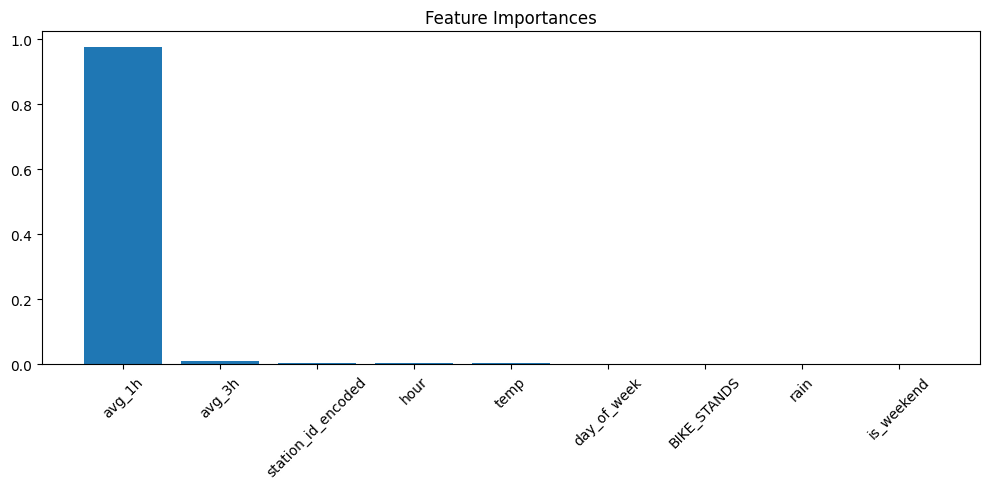

In [10]:
importances = rfr_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.title("Feature Importances")
plt.bar(range(len(features)), importances[indices])
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

## Interpreting the Feature Importance
Obviously, the availability of the bikes was the most important factor in whether or not a bike was available on the prediction model. The other factors are more interesting, suggesting a correlation between the exact hour and temperature in whether a bike was available at the station.

The natural recommendation, given those results, is to go back to the feature engineering process and check if another approach would not be more suitable. Maybe January is just an uneventful month for rentals, who knows?

**Note:** This would not be possible, as almost every data set they have has different rows in the data set.

It should be noted that this is still a valid approach, but more rental usage would increase the quality of the set. As would increasing the amount of data, maybe using the summer months, but the file size for this project is large enough already.

# Conclusions
Overall, this project really demonstrated the need for good quality data for Machine Learning models. The data used demonstrated that while accurate conclusions could be drawn from it, more data will always improve the model in question. The conclusions drew somewhat of a conclusion between external factors and the rate of bike rentals, by measuring the availability of bikes against these factors.

Also of note, on the DublinBikes website, it states that bikes are only available to be rented between 05:00 and 12:30, meaning that most of the data set is irrelevant, as they record every hour.

# Extras
To download the merged data set, uncomment the two lines in the code cell below.

In [13]:
# merged_df.to_csv('merged_df.csv')
# files.download('merged_df.csv')